# Power Usage Analysis in Romania (2016-2020) using CBR-FoX

## 1. Import Necessary Libraries

In [1]:
import sys
import os
import numpy as np

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from cbr_fox.core import cbr_fox
from cbr_fox.builder import cbr_fox_builder
from cbr_fox.custom_distance import cci_distance

## 2. Load the Saved Data   

In [2]:
# Load the saved data
# Load the saved data from parent/Weather_forecasting folder
npz_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'Weather_forecasting', 'weather_forecasting.npz'))
data = np.load(npz_path)

## 3. Retrieve Variables from the Data

In [3]:
# Retrieve each variable
training_windows = data['training_windows']
forecasted_window = data['forecasted_window']
target_training_windows = data['target_training_windows']
windowsLen = data['windowsLen'].item()  # Extract single value from array
componentsLen = data['componentsLen'].item()
windowLen = data['windowLen'].item()
prediction = data['prediction']

## 4. Define CBR-FoX Techniques

In [4]:
# Define the CBR-FoX techniques with custom distance metrics
techniques = [
    cbr_fox(metric=cci_distance,smoothness_factor=.04 ,kwargs={"punished_sum_factor": .5})
]

## 5. Build and Train the CBR-FoX Model

In [5]:
# Initialize the CBR-FoX builder
p = cbr_fox_builder(techniques)

# Train the model with the provided data
p.fit(training_windows = training_windows,
      target_training_windows = target_training_windows,
        forecasted_window = forecasted_window)

2025-10-18 00:24:05,125 - INFO - Analizando conjunto de datos
2025-10-18 00:24:05,125 - INFO - Calculando Correlación


DEBUG: cbr_fox_builder.__init__ called
DEBUG: techniques parameter type: <class 'list'>
DEBUG: techniques parameter value: [<cbr_fox.core.cbr_fox.cbr_fox object at 0x00000164BADA56D0>]
DEBUG: techniques length: 1
DEBUG: Starting loop through techniques...
DEBUG: Processing item 0: <cbr_fox.core.cbr_fox.cbr_fox object at 0x00000164BADA56D0>
DEBUG: Item type: <class 'cbr_fox.core.cbr_fox.cbr_fox'>
DEBUG: Item has 'metric' attribute
DEBUG: item.metric = <function cci_distance at 0x00000164BAD29A80>
DEBUG: item.metric type = <class 'function'>
DEBUG: Metric is not string, checking for __name__ attribute...
DEBUG: item.metric.__name__ = cci_distance
DEBUG: Adding to dict with key: 'cci_distance'
DEBUG: Successfully added callable metric to dict
DEBUG: Final techniques_dict keys: ['cci_distance']
DEBUG: cbr_fox_builder.__init__ completed successfully


Windows procesadas:   0%|          | 0/6835 [00:00<?, ?it/s]2025-10-18 00:24:05,368 - INFO - Applyiing Pearson Correlation
2025-10-18 00:24:05,368 - WARNING - Failed with sktime metric: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices
Windows procesadas:   0%|          | 0/6835 [00:00<?, ?it/s]
2025-10-18 00:24:05,368 - INFO - Applyiing Pearson Correlation
Windows procesadas: 100%|██████████| 6835/6835 [00:01<00:00, 4188.19it/s]
2025-10-18 00:24:07,000 - INFO - Applying Euclidean Distance
Windows procesadas: 100%|██████████| 6835/6835 [00:00<00:00, 18585.61it/s]
2025-10-18 00:24:07,375 - INFO - Computando análisis de CBR
2025-10-18 00:24:07,375 - INFO - Suavizando Correlación
2025-10-18 00:24:07,847 - INFO - Extrayendo crestas y valles
2025-10-18 00:24:07,847 - INFO - Recuperando segmentos convexos y cóncavos
2025-10-18 00:24:07,847 - INFO - Recuperando índices originales de correlación
Segmentos convexos: 100%|██████

## 6. Visualize correlation per window

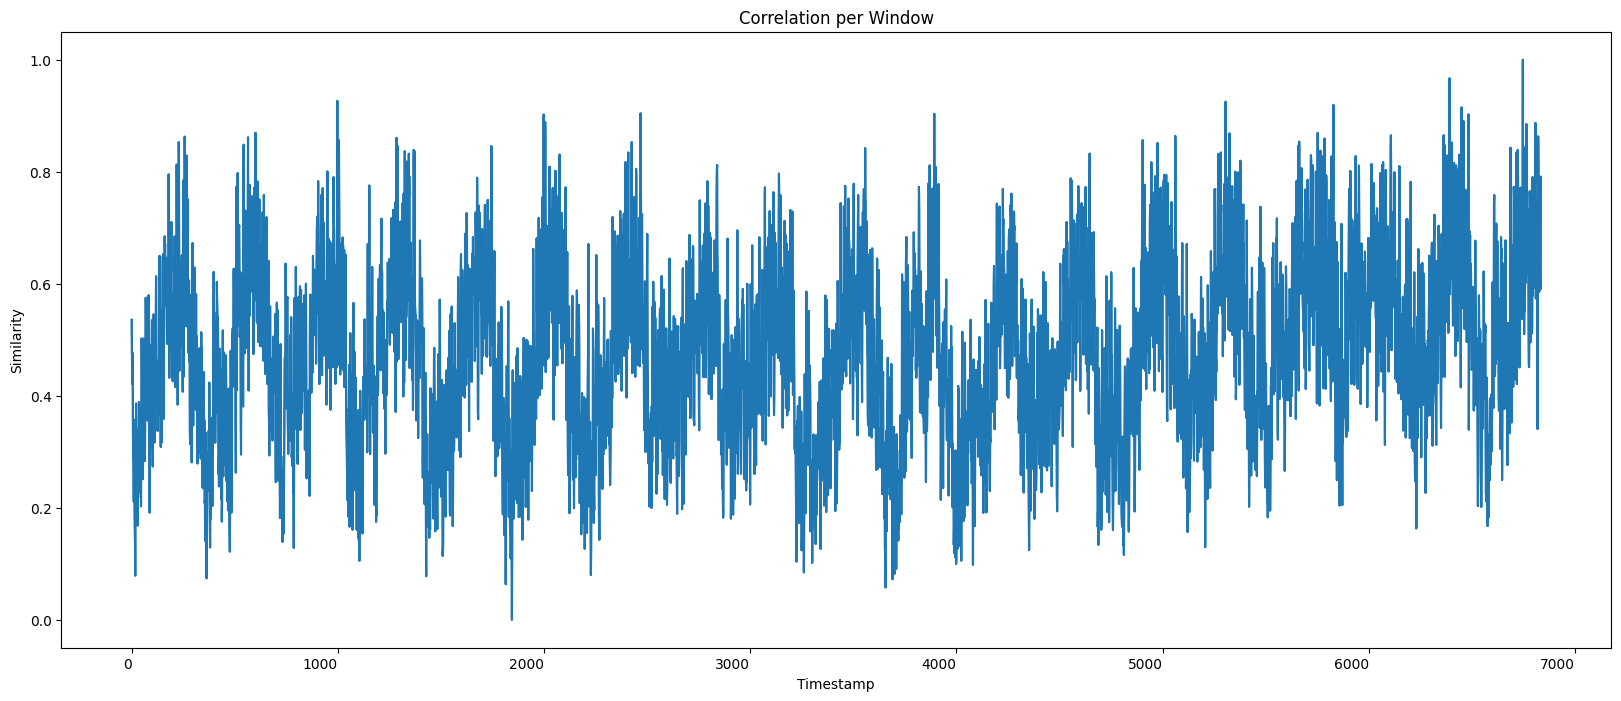

[(<Figure size 2000x800 with 1 Axes>,
  <Axes: title={'center': 'Correlation per Window'}, xlabel='Timestamp', ylabel='Similarity'>)]

In [14]:
p.visualize_pyplot(mode="correlation", fig_size=(20,8), plot_params={"color":'#1F77B4'},xlabel = "Timestamp", ylabel = "Similarity", legend=False)

## 7. Visualize smoothed correlation per window

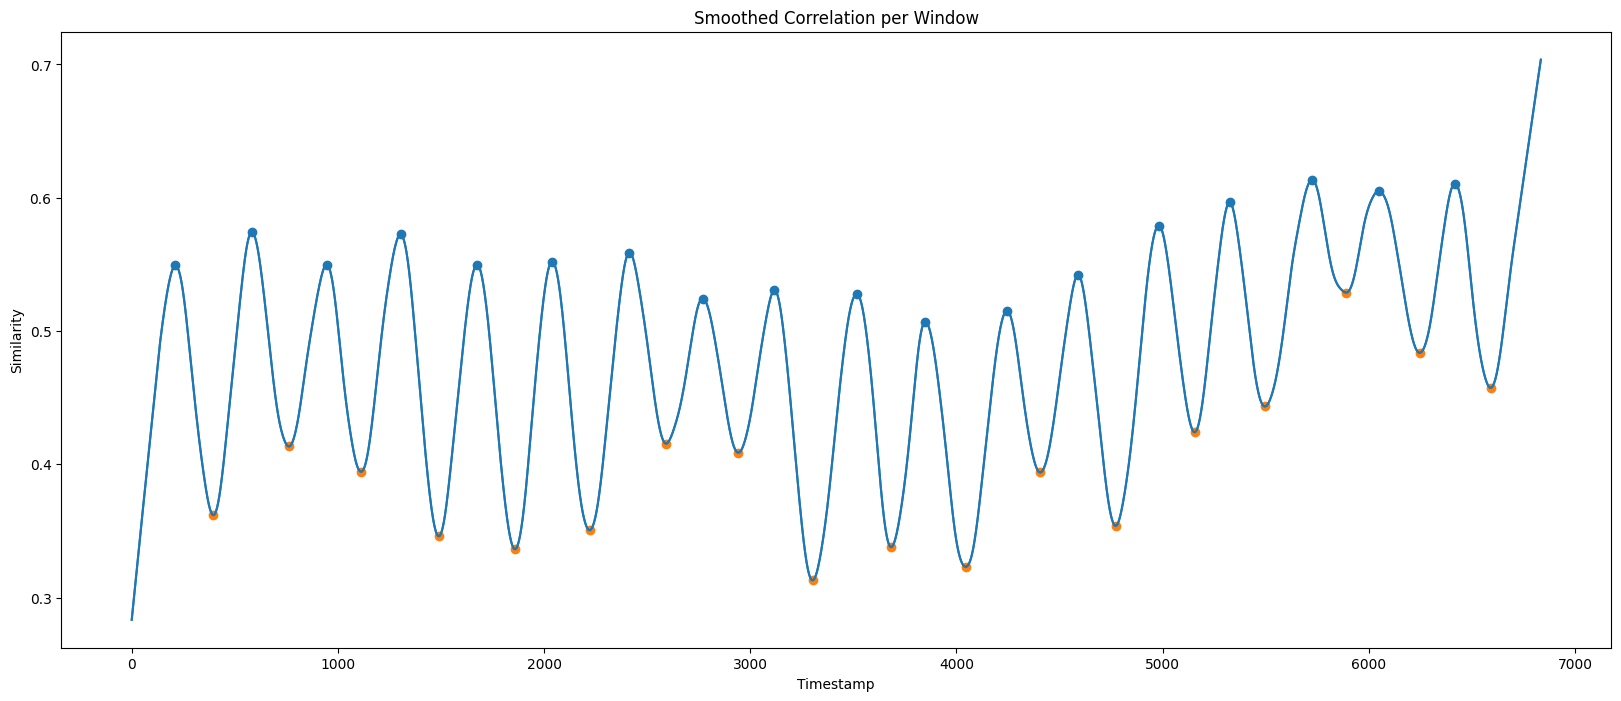

[(<Figure size 2000x800 with 1 Axes>,
  <Axes: title={'center': 'Smoothed Correlation per Window'}, xlabel='Timestamp', ylabel='Similarity'>)]

In [15]:
p.visualize_pyplot(mode="smoothed", fig_size=(20,8), plot_params={"color":'#1F77B4'},xlabel = "Timestamp", ylabel = "Similarity", legend=False)

In [8]:
# Make predictions and generate explanations
p.predict(prediction = prediction,num_cases=3)

2025-10-18 00:24:08,270 - INFO - Generando reporte de análisis


## 8. Visualize analysis report

In [9]:
p.techniques_dict['cci_distance'].get_analysis_report()

,index,window,target_window,correlation,MAE
0,6834,"[[29.45, 33.8288029, 85.85129869], [28.65, 33....","[28.65, 33.60568572, 88.99294254]",0.790772,1.510403
1,1675,"[[28.95, 30.1, 87.0], [29.4, 29.8, 81.0], [29....","[29.4, 29.8, 81.0]",0.789289,2.672473
2,5725,"[[30.15, 32.9, 82.0], [30.35, 32.4, 83.0], [30...","[30.35, 32.4, 83.0]",0.731637,1.944238
3,4045,"[[20.35, 16.1, 67.0], [19.75, 15.7, 65.0], [24...","[19.75, 15.7, 65.0]",0.212617,15.755806
4,3302,"[[20.35, 18.7, 76.0], [20.15, 16.8, 69.0], [22...","[20.15, 16.8, 69.0]",0.164003,13.922473
5,1112,"[[20.1, 18.3, 81.0], [18.0, 15.2, 74.0], [17.5...","[18.0, 15.2, 74.0]",0.159053,13.505806


## 9. Visualize results per component

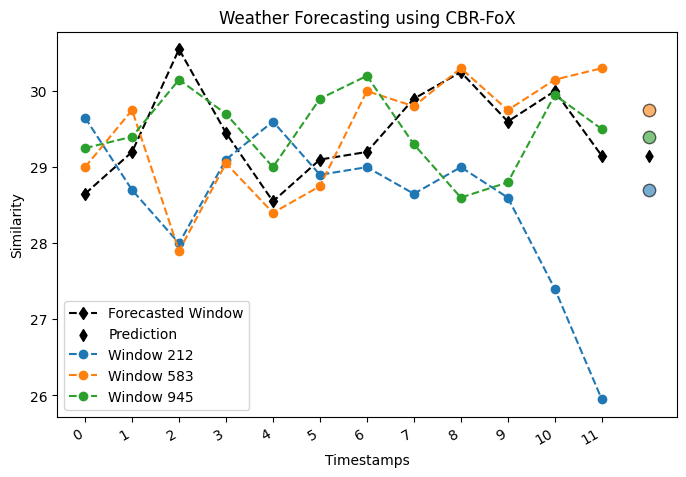

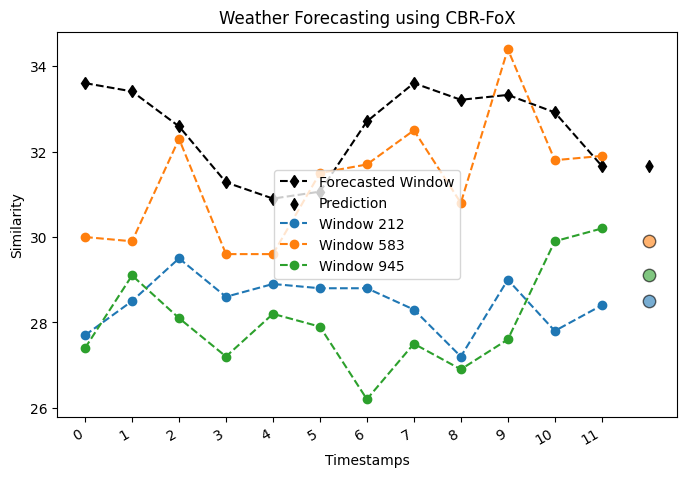

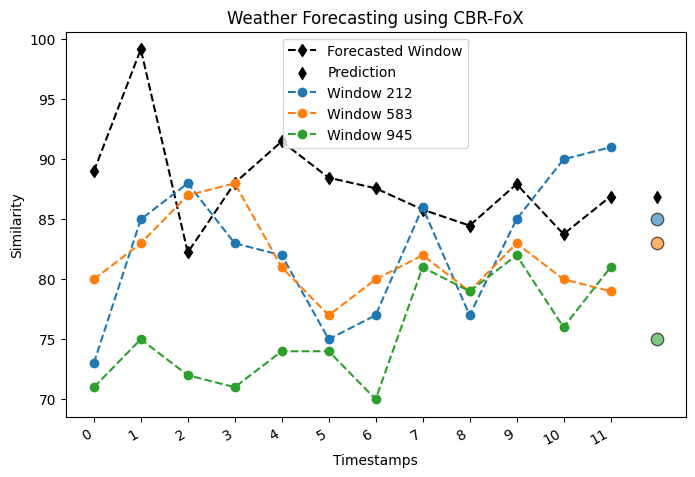

[[(<Figure size 800x500 with 1 Axes>,
   <Axes: title={'center': 'Weather Forecasting using CBR-FoX'}, xlabel='Timestamps', ylabel='Similarity'>),
  (<Figure size 800x500 with 1 Axes>,
   <Axes: title={'center': 'Weather Forecasting using CBR-FoX'}, xlabel='Timestamps', ylabel='Similarity'>),
  (<Figure size 800x500 with 1 Axes>,
   <Axes: title={'center': 'Weather Forecasting using CBR-FoX'}, xlabel='Timestamps', ylabel='Similarity'>)]]

In [10]:
# Visualize the predictions and results
p.visualize_pyplot(
    fmt = '--o',
    legend = True,
    n_windows = 3,
    fig_size = (8, 5),
    scatter_params = {"s": 80, "alpha": 0.6, "edgecolors": "black"},
    xtick_rotation = 30,
    title="Weather Forecasting using CBR-FoX",
    xlabel="Timestamps",
    ylabel="Similarity",
)

## 10. Visualize combined results

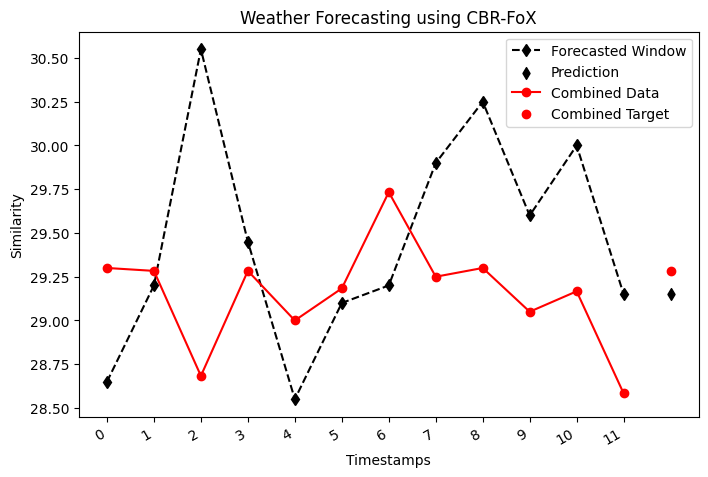

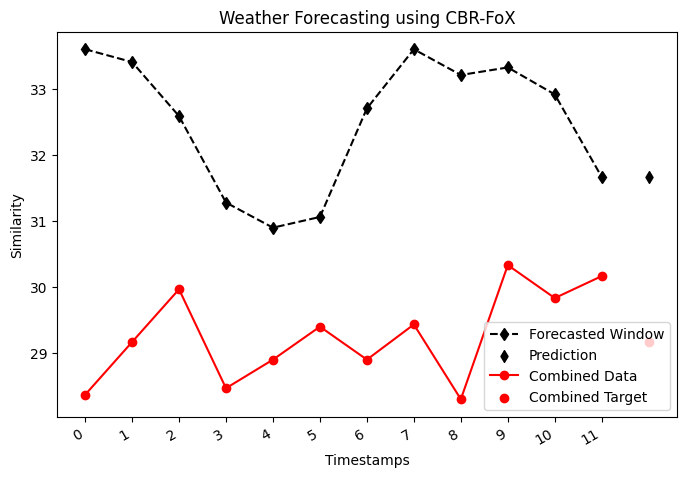

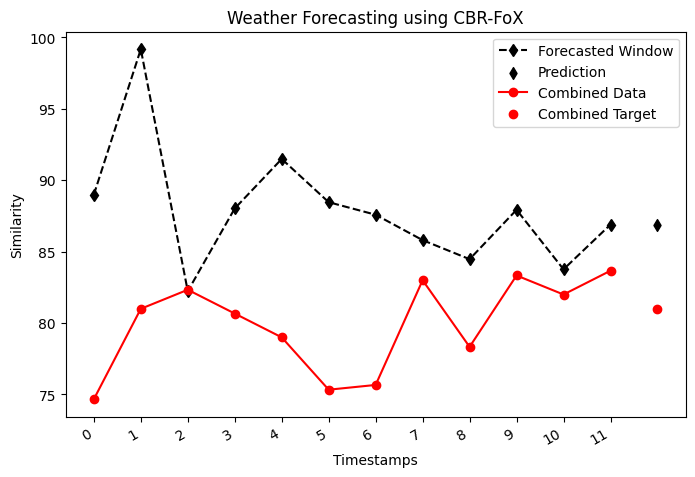

[[(<Figure size 800x500 with 1 Axes>,
   <Axes: title={'center': 'Weather Forecasting using CBR-FoX'}, xlabel='Timestamps', ylabel='Similarity'>),
  (<Figure size 800x500 with 1 Axes>,
   <Axes: title={'center': 'Weather Forecasting using CBR-FoX'}, xlabel='Timestamps', ylabel='Similarity'>),
  (<Figure size 800x500 with 1 Axes>,
   <Axes: title={'center': 'Weather Forecasting using CBR-FoX'}, xlabel='Timestamps', ylabel='Similarity'>)]]

In [11]:
p.visualize_pyplot(
    fmt = '--o',
    legend = True,
    mode = "combined",
    n_windows = 3,
    fig_size = (8, 5),
    scatter_params = {"s": 80, "alpha": 0.6, "edgecolors": "black"},
    xtick_rotation = 30,
    title="Weather Forecasting using CBR-FoX",
    xlabel="Timestamps",
    ylabel="Similarity",
)